# What does the poster model look at, when can you trust it, and are its mistakes really mistakes?

This notebook explains the **demo model**, which is ResNet50 with its last block fine-tuned, trained on split 0 by [`movie_genre_classification.ipynb`](movie_genre_classification.ipynb). It answers three questions:

1. **When can you trust a prediction?** It compares the model's confidence with how often it is actually right on held-out test posters.
2. **What does the model look at?** [Grad-CAM](https://arxiv.org/abs/1610.02391) highlights the parts of a poster that drive the predicted genre. Average heatmaps per genre show *where* on a poster each genre's evidence tends to sit.
3. **Are the mistakes really mistakes?** IMDb lists all of a film's genres, while the dataset gives each film only one. Checking the model's errors against IMDb shows how many of them are actually real secondary genres.

Everything here uses the saved checkpoint in `models/`, so nothing is retrained.

## 1. Setup

In [1]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("postergenre"):  # Colab: fetch the repo's package
    !git clone -q https://github.com/RachitSethi2455/movie-genre-poster-classification.git
    %cd movie-genre-poster-classification
    !pip install -q kagglehub

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from postergenre.data import PosterDataset, download_posters, eval_tf, list_images, load_image, stratified_split
from postergenre.gradcam import GradCAM, overlay
from postergenre.models import build_model, load_trained_state
from postergenre.train import predict

ASSETS, MODELS = Path("assets"), Path("models")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")

card = json.loads((MODELS / "model_card.json").read_text(encoding="utf-8"))
model = build_model(card["backbone"], len(card["classes"]))
load_trained_state(model, torch.load(MODELS / "poster_genre.pth", map_location="cpu"))
model = model.float().to(device).eval()
class_names = card["classes"]
print("Device:", device, "| model:", card["backbone"], "(fine-tuned)" if card["fine_tuned"] else "(frozen)")

Device: cuda | model: ResNet50 (fine-tuned)


## 2. Rebuild the demo model's test set
The demo model was trained on split seed 0, so its held-out test set is that split's 199 posters. Re-scoring them should reproduce the accuracy recorded in the model card, within a poster or two because the checkpoint is stored in fp16. That confirms this notebook explains the same model and the same unseen posters.

In [3]:
paths, labels, names = list_images(download_posters())
assert names == class_names
test_paths, test_labels = stratified_split(paths, labels, card["split_seed"])["test"]
images = {p: load_image(p) for p in test_paths}
loader = DataLoader(PosterDataset(test_paths, test_labels, images, eval_tf), batch_size=32)
y_true, y_pred, probs = predict(model, loader, device)
conf = probs.max(1)
correct = y_true == y_pred
print(f"Test accuracy: {correct.mean():.1%} on {len(y_true)} posters (model card: {card['test_acc_split0']:.1f}%)")
# The checkpoint stores weights in fp16, so a poster right on a decision boundary may flip; allow up to 2 posters.
assert abs(100 * correct.mean() - card["test_acc_split0"]) <= 1.01, "this does not look like the demo model's test set"

Test accuracy: 68.8% on 199 posters (model card: 69.3%)


## 3. When can you trust a prediction?
The demo shows a probability for each genre. Is the top probability, the model's **confidence**, a useful signal? The analysis has three parts:
- **Accuracy by confidence band**: how often the model is right when it reports a given confidence.
- **Accuracy vs coverage**: if the model only answered when its confidence passed a threshold, how accurate would it be, and on what share of posters would it answer?
- **Reliability diagram**: whether the reported confidence matches the observed accuracy.

With 199 test posters some bands are small, so the counts are shown alongside each number.

,Posters,Accuracy,Share of posters
band,,,
< 40%,10,20%,5%
40–60%,64,52%,32%
60–80%,71,75%,36%
≥ 80%,54,91%,27%


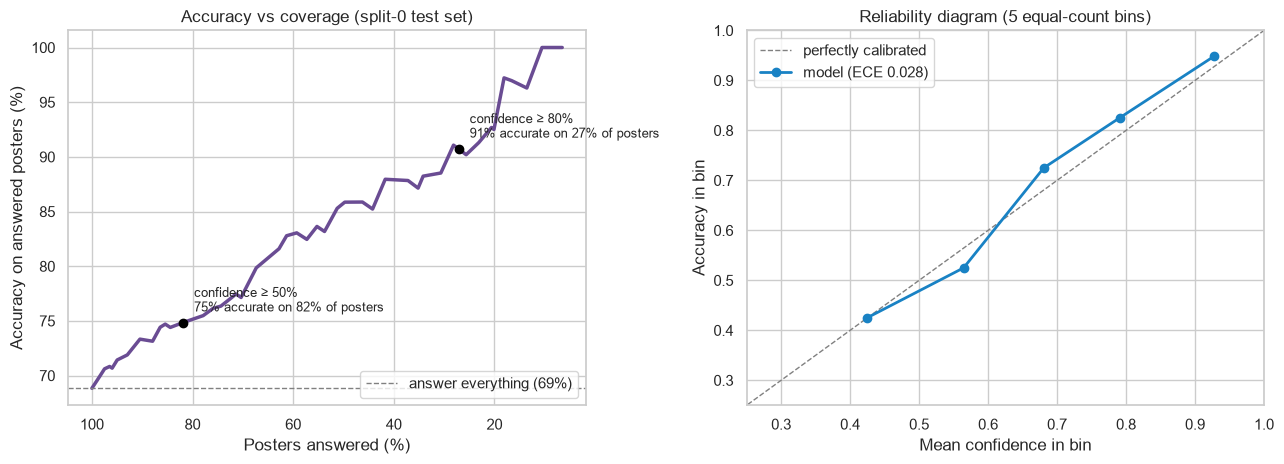

In [4]:
bands = pd.cut(conf, [0, 0.4, 0.6, 0.8, 1.0], labels=["< 40%", "40–60%", "60–80%", "≥ 80%"], include_lowest=True)
by_band = (pd.DataFrame({"band": bands, "correct": correct}).groupby("band", observed=False)["correct"]
           .agg(["size", "mean"]).rename(columns={"size": "Posters", "mean": "Accuracy"}))
by_band["Share of posters"] = by_band["Posters"] / len(conf)
display(by_band.style.format({"Accuracy": "{:.0%}", "Share of posters": "{:.0%}"}))

thresholds = np.linspace(0.25, 0.95, 57)
coverage = np.array([(conf >= t).mean() for t in thresholds])
selective_acc = np.array([correct[conf >= t].mean() if (conf >= t).any() else np.nan for t in thresholds])

order = np.argsort(conf)
bins = np.array_split(order, 5)  # 5 equal-count bins of about 40 posters each
rel = pd.DataFrame({"confidence": [conf[b].mean() for b in bins], "accuracy": [correct[b].mean() for b in bins]})
ece = (rel["confidence"] - rel["accuracy"]).abs().mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(coverage * 100, selective_acc * 100, color="#6a4c93", lw=2.5)
for t in (0.5, 0.8):
    i = np.argmin(np.abs(thresholds - t))
    axes[0].scatter(coverage[i] * 100, selective_acc[i] * 100, color="black", zorder=3)
    axes[0].annotate(f"confidence ≥ {t:.0%}\n{selective_acc[i]:.0%} accurate on {coverage[i]:.0%} of posters",
                     (coverage[i] * 100, selective_acc[i] * 100), textcoords="offset points", xytext=(8, 8), fontsize=9)
axes[0].axhline(correct.mean() * 100, color="grey", ls="--", lw=1, label=f"answer everything ({correct.mean():.0%})")
axes[0].set(xlabel="Posters answered (%)", ylabel="Accuracy on answered posters (%)", title="Accuracy vs coverage (split-0 test set)")
axes[0].invert_xaxis()
axes[0].legend(loc="lower right")
axes[1].plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="perfectly calibrated")
axes[1].plot(rel["confidence"], rel["accuracy"], marker="o", color="#1982c4", lw=2, label=f"model (ECE {ece:.3f})")
axes[1].set(xlim=(0.25, 1), ylim=(0.25, 1), xlabel="Mean confidence in bin", ylabel="Accuracy in bin",
            title="Reliability diagram (5 equal-count bins)")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.savefig(ASSETS / "confidence.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. What does the model look at? Grad-CAM on test posters
Grad-CAM takes the gradient of the predicted genre's score with respect to ResNet50's last convolutional block (`layer4`, a 7×7 grid of features) and highlights the regions that push the prediction towards that genre. Red means strong evidence and blue means little.

The posters below are the model's **most confident correct predictions** for each genre. Thumbnails are kept small.

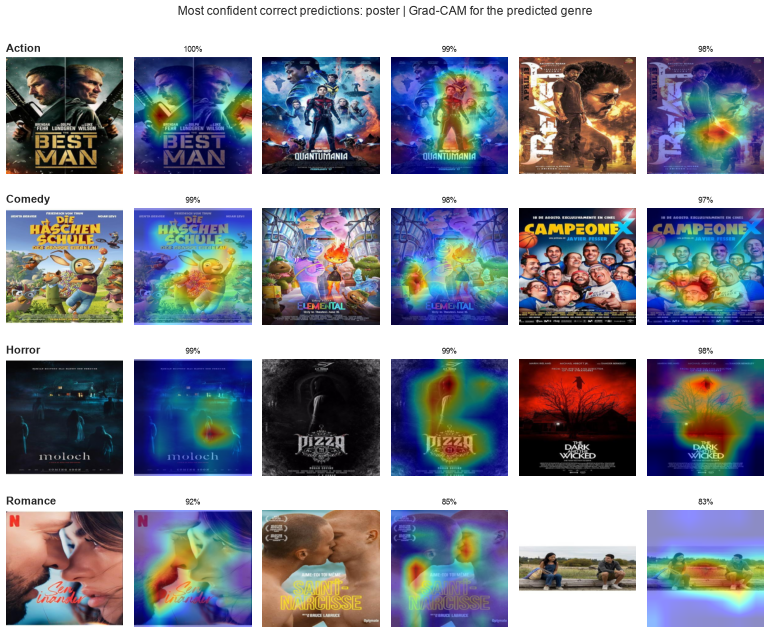

In [5]:
def heatmaps(path_list, class_idx=None):
    x = torch.stack([eval_tf(images[p]) for p in path_list]).to(device)
    with GradCAM(model, model.layer4) as cam:
        return cam(x, class_idx)


with plt.rc_context({"figure.dpi": 60}):
    fig, axes = plt.subplots(len(class_names), 6, figsize=(13, 2.7 * len(class_names)))
    for r, genre in enumerate(class_names):
        idx = [i for i in np.argsort(-conf) if correct[i] and y_true[i] == r][:3]
        heat, _ = heatmaps([test_paths[i] for i in idx])
        for c, (i, h) in enumerate(zip(idx, heat)):
            axes[r, 2 * c].imshow(images[test_paths[i]])
            axes[r, 2 * c + 1].imshow(overlay(images[test_paths[i]], h))
            axes[r, 2 * c + 1].set_title(f"{conf[i]:.0%}", fontsize=10)
        axes[r, 0].set_title(genre, loc="left", fontsize=13, fontweight="bold")
        for ax in axes[r]:
            ax.axis("off")
    plt.suptitle("Most confident correct predictions: poster | Grad-CAM for the predicted genre", y=1.0)
    plt.tight_layout()
    plt.show()

### Confident mistakes
The most instructive errors are the ones the model was *sure* about. Each heatmap shows the evidence for the **wrong** genre it predicted.

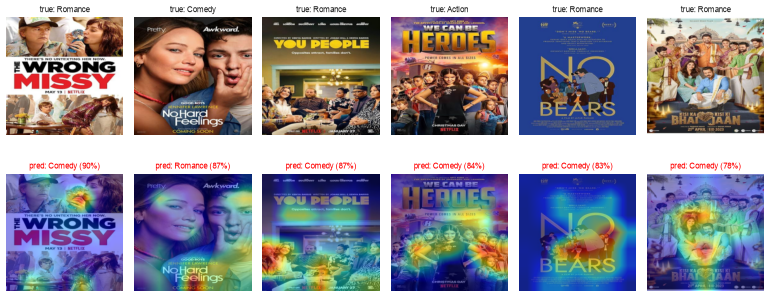

Confusions among the 6 most confident mistakes: {'Romance -> Comedy': 4, 'Comedy -> Romance': 1, 'Action -> Comedy': 1}


In [6]:
wrong = [i for i in np.argsort(-conf) if not correct[i]][:6]
heat, _ = heatmaps([test_paths[i] for i in wrong])
with plt.rc_context({"figure.dpi": 60}):
    fig, axes = plt.subplots(2, 6, figsize=(13, 5.8))
    for c, (i, h) in enumerate(zip(wrong, heat)):
        axes[0, c].imshow(images[test_paths[i]])
        axes[0, c].set_title(f"true: {class_names[y_true[i]]}", fontsize=10)
        axes[1, c].imshow(overlay(images[test_paths[i]], h))
        axes[1, c].set_title(f"pred: {class_names[y_pred[i]]} ({conf[i]:.0%})", fontsize=10, color="red")
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
print("Confusions among the 6 most confident mistakes:",
      pd.Series([f"{class_names[y_true[i]]} -> {class_names[y_pred[i]]}" for i in wrong]).value_counts().to_dict())

## 5. Where on a poster is each genre's evidence?
Averaging Grad-CAM over **every correctly classified test poster** of a genre shows where the model typically finds that genre's evidence. These averages contain no poster content. The bar chart splits the attention into the top quarter of the poster, where titles and taglines usually sit, the middle half (main image and characters) and the bottom quarter (title block and credits).

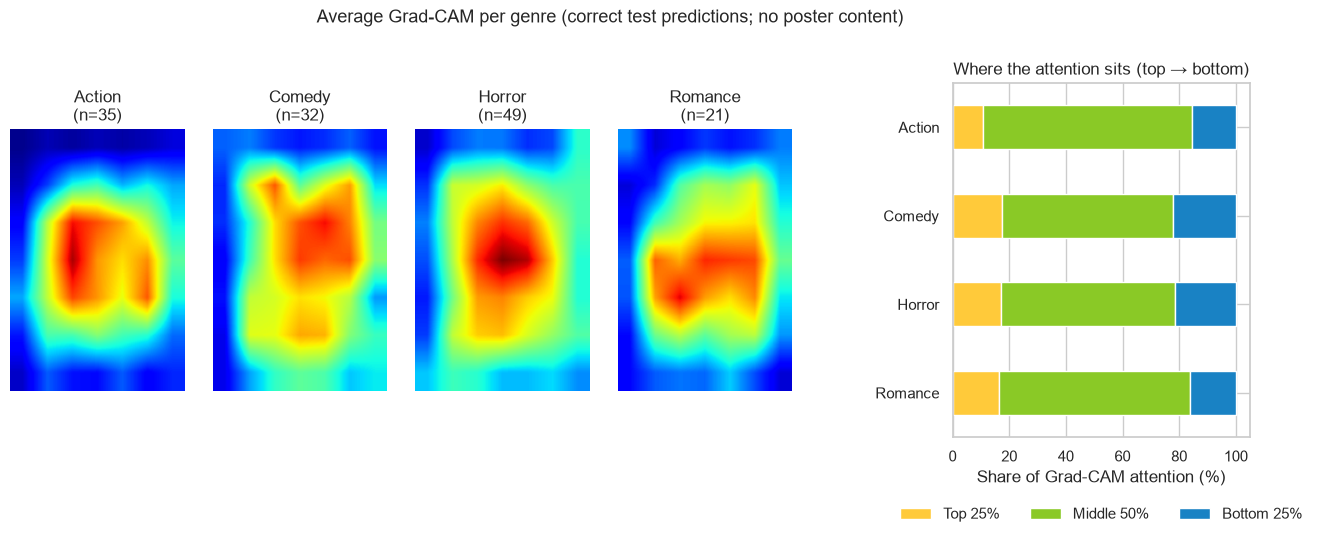

,Posters,Top 25%,Middle 50%,Bottom 25%
Genre,,,,
Action,35,11%,74%,15%
Comedy,32,17%,60%,22%
Horror,49,17%,61%,21%
Romance,21,16%,67%,16%


In [7]:
mean_maps, regions = {}, []
for r, genre in enumerate(class_names):
    idx = [i for i in range(len(test_paths)) if correct[i] and y_true[i] == r]
    heat = np.concatenate([heatmaps([test_paths[i] for i in idx[k:k + 32]])[0] for k in range(0, len(idx), 32)])
    mean_maps[genre] = heat.mean(0)
    mass = heat / np.maximum(heat.sum(axis=(1, 2), keepdims=True), 1e-8)
    rows = mass.sum(2)  # per-row share of each heatmap's attention, top to bottom
    q = rows.shape[1] // 4
    regions.append({"Genre": genre, "Posters": len(idx), "Top 25%": rows[:, :q].sum(1).mean(),
                    "Middle 50%": rows[:, q:3 * q].sum(1).mean(), "Bottom 25%": rows[:, 3 * q:].sum(1).mean()})
regions = pd.DataFrame(regions).set_index("Genre")

fig = plt.figure(figsize=(16, 4.6))
grid = fig.add_gridspec(1, len(class_names) + 2, width_ratios=[1] * len(class_names) + [0.6, 1.7], wspace=0.15)
vmax = max(m.max() for m in mean_maps.values())
for k, genre in enumerate(class_names):
    ax = fig.add_subplot(grid[0, k])
    im = ax.imshow(mean_maps[genre], cmap="jet", vmin=0, vmax=vmax, aspect=1.5)  # posters are about 2:3
    ax.set_title(f"{genre}\n(n={regions.loc[genre, 'Posters']})")
    ax.axis("off")
ax = fig.add_subplot(grid[0, -1])
regions[["Top 25%", "Middle 50%", "Bottom 25%"]].mul(100).plot.barh(stacked=True, ax=ax, color=["#ffca3a", "#8ac926", "#1982c4"])
ax.set(xlabel="Share of Grad-CAM attention (%)", ylabel="", title="Where the attention sits (top → bottom)")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
fig.suptitle("Average Grad-CAM per genre (correct test predictions; no poster content)", y=1.04, fontsize=13)
plt.savefig(ASSETS / "gradcam_mean.png", dpi=120, bbox_inches="tight")
plt.show()
regions.style.format({"Top 25%": "{:.0%}", "Middle 50%": "{:.0%}", "Bottom 25%": "{:.0%}"})

## 6. Are the mistakes really mistakes? Checking against IMDb
Every poster file is named by its IMDb title ID (`tt…`), and IMDb lists **all** of a film's genres. The dataset, by contrast, files each poster under exactly one. Joining the two shows:
1. how often a film really belongs to more than one of the four genres, and
2. how often a model "mistake" predicts a genre the film actually has. These are compared with a random wrong guess.

The genres come from IMDb's non-commercial dataset [`title.basics.tsv.gz`](https://developer.imdb.com/non-commercial-datasets/). It is downloaded on demand (about 230 MB) and never committed; only derived statistics appear here. *Information courtesy of IMDb (https://www.imdb.com). Used with permission.*

In [8]:
from postergenre.imdb import imdb_genres

ids = [Path(p).stem for p in paths]
imdb = imdb_genres(ids)
label_of = {Path(p).stem: class_names[l] for p, l in zip(paths, labels)}
four = set(class_names)
in_four = {t: g & four for t, g in imdb.items()}
print(f"Posters found on IMDb with genres: {len(imdb)} of {len(ids)}")
print(f"Dataset label is one of the film's IMDb genres: {np.mean([label_of[t] in g for t, g in imdb.items()]):.0%}")
print(f"Films with 2+ of the four genres on IMDb:       {np.mean([len(g) >= 2 for g in in_four.values()]):.0%}")

# Rows: the dataset's single label. Columns: share of those films that IMDb also files under each genre.
overlap = pd.DataFrame({genre: [np.mean([genre in imdb[t] for t in imdb if label_of[t] == lab]) for lab in class_names]
                        for genre in class_names}, index=class_names)
overlap.index.name = "Dataset label"
overlap.style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0, vmax=1)

Posters found on IMDb with genres: 1245 of 1325
Dataset label is one of the film's IMDb genres: 97%
Films with 2+ of the four genres on IMDb:       24%


,Action,Comedy,Horror,Romance
Dataset label,,,,
Action,97%,18%,2%,1%
Comedy,9%,96%,2%,4%
Horror,7%,9%,98%,1%
Romance,3%,52%,1%,97%


Split-0 test errors with IMDb genres: 62
Errors where the predicted genre IS one of the film's IMDb genres: 50% (a random wrong guess: 19%)
Accuracy if any IMDb genre counts as correct: 84.4% (strict single-label: 68.8%)


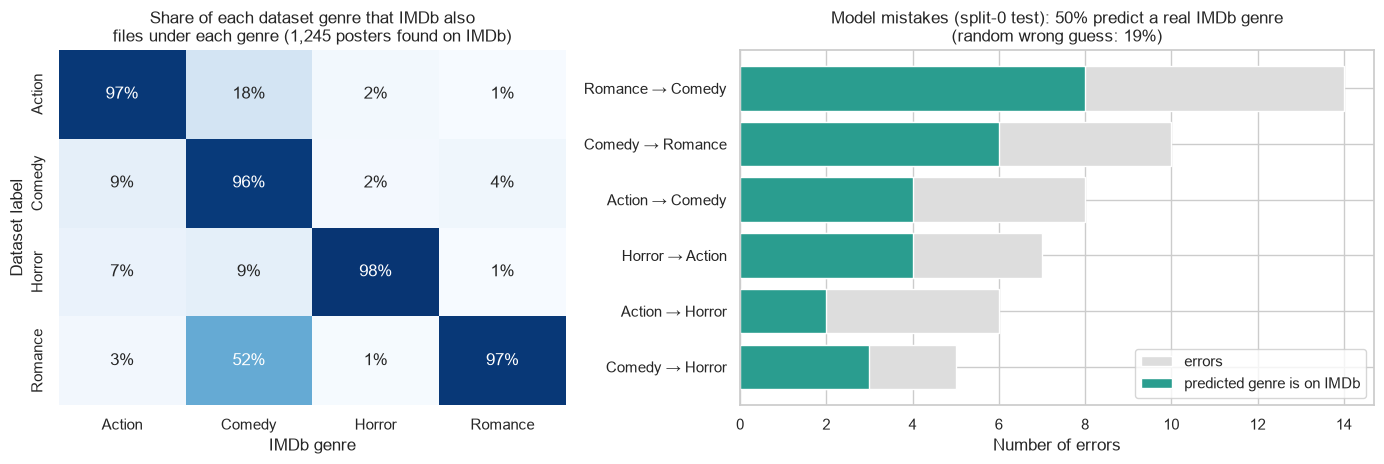

,Errors,Share_on_IMDb
Confusion,,
Romance → Comedy,14,57%
Comedy → Romance,10,60%
Action → Comedy,8,50%
Horror → Action,7,57%
Action → Horror,6,33%
Comedy → Horror,5,60%
Horror → Comedy,3,67%
Romance → Horror,3,0%
Romance → Action,2,0%


In [9]:
test_ids = [Path(p).stem for p in test_paths]
errors = [i for i in range(len(test_ids)) if not correct[i] and test_ids[i] in imdb]
pred_has = np.array([class_names[y_pred[i]] in imdb[test_ids[i]] for i in errors])
# A random wrong guess picks one of the 3 other genres; its chance of hitting a real IMDb genre:
random_has = np.mean([len((imdb[test_ids[i]] & four) - {class_names[y_true[i]]}) / 3 for i in errors])
lenient = np.mean([correct[i] or class_names[y_pred[i]] in imdb.get(test_ids[i], set()) for i in range(len(test_ids))])

print(f"Split-0 test errors with IMDb genres: {len(errors)}")
print(f"Errors where the predicted genre IS one of the film's IMDb genres: {pred_has.mean():.0%} "
      f"(a random wrong guess: {random_has:.0%})")
print(f"Accuracy if any IMDb genre counts as correct: {lenient:.1%} (strict single-label: {correct.mean():.1%})")

pairs = pd.DataFrame({"Confusion": [f"{class_names[y_true[i]]} → {class_names[y_pred[i]]}" for i in errors], "On IMDb": pred_has})
by_pair = pairs.groupby("Confusion")["On IMDb"].agg(Errors="size", Share_on_IMDb="mean").sort_values("Errors", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.25]})
sns.heatmap(overlap, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=axes[0])
axes[0].set(title=f"Share of each dataset genre that IMDb also\nfiles under each genre ({len(imdb):,} posters found on IMDb)",
            xlabel="IMDb genre", ylabel="Dataset label")
top = by_pair.head(6)[::-1]
axes[1].barh(top.index, top["Errors"], color="#dddddd", label="errors")
axes[1].barh(top.index, top["Errors"] * top["Share_on_IMDb"], color="#2a9d8f", label="predicted genre is on IMDb")
axes[1].set(title=f"Model mistakes (split-0 test): {pred_has.mean():.0%} predict a real IMDb genre\n"
                  f"(random wrong guess: {random_has:.0%})", xlabel="Number of errors")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig(ASSETS / "imdb_genres.png", dpi=120, bbox_inches="tight")
plt.show()
by_pair.style.format({"Share_on_IMDb": "{:.0%}"})

## 7. Takeaways

In [10]:
i50, i80 = (np.argmin(np.abs(thresholds - t)) for t in (0.5, 0.8))
print(f"Overall accuracy           : {correct.mean():.1%}")
print(f"Confidence >= 80%          : {selective_acc[i80]:.0%} accurate on {coverage[i80]:.0%} of posters")
print(f"Confidence <  40%          : {by_band.loc['< 40%', 'Accuracy']:.0%} accurate ({by_band.loc['< 40%', 'Posters']} posters)")
print(f"Expected calibration error : {ece:.3f}")
for genre, row in regions.iterrows():
    print(f"{genre:<8} attention       : top {row['Top 25%']:.0%} / middle {row['Middle 50%']:.0%} / bottom {row['Bottom 25%']:.0%}")
print(f"Errors with a real IMDb genre: {pred_has.mean():.0%} (random wrong guess {random_has:.0%})")
print(f"Lenient accuracy (any IMDb genre): {lenient:.1%}")

Overall accuracy           : 68.8%
Confidence >= 80%          : 91% accurate on 27% of posters
Confidence <  40%          : 20% accurate (10 posters)
Expected calibration error : 0.028
Action   attention       : top 11% / middle 74% / bottom 15%
Comedy   attention       : top 17% / middle 60% / bottom 22%
Horror   attention       : top 17% / middle 61% / bottom 21%
Romance  attention       : top 16% / middle 67% / bottom 16%
Errors with a real IMDb genre: 50% (random wrong guess 19%)
Lenient accuracy (any IMDb genre): 84.4%


- **The demo's confidence can be taken roughly at face value.** When the model reports at least 80% confidence it is right **91%** of the time, and that covers about a quarter of posters. Below 40% it is right only 20% of the time, close to the 25% of random guessing. Calibration error is 0.028. With 199 test posters these are estimates, not precise rates.
- **The model reads the image, not the title.** On average, 60–74% of the Grad-CAM attention falls in the middle half of the poster, against the 50% a uniform map would give. Action is the most centred (74%), while Comedy and Horror spread more towards the top and bottom (about 38–39%), where titles and taglines sit. Grad-CAM on ResNet50's 7×7 feature grid is coarse, so this shows regions, not individual letters.
- **What it looks at, in the examples:** for Romance, a couple's faces close together; for Horror, a dark, isolated central figure; for Action, the armed hero; for Comedy, groups of characters or cartoon figures.
- **Many "mistakes" are right according to IMDb.** The dataset files each film under one genre, but on IMDb 24% of these films belong to two or more of the four genres, and **52% of the 'Romance' films are also Comedies**. Of the model's 62 errors on the split-0 test set, **50% predicted a genre the film really has on IMDb**, against 19% for a random wrong guess. Counting any IMDb genre as correct raises accuracy from 68.8% to **84.4%**. The Romance ↔ Comedy confusion is largely the data's single-genre labels, not the model; romantic comedies such as *The Wrong Missy* and *You People* are typical.